<a href="https://colab.research.google.com/github/PabloXberg/Project-3-Ironhack/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Preprocessing & Visualization

Using device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Sample images from the dataset:


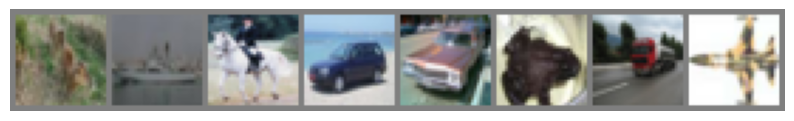

deer  ship  horse car   car   frog  truck plane


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Data Preprocessing & Augmentation
# We add a random flip to the training data to prevent overfitting
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalizes pixel values
])

# Test data shouldn't be augmented, just converted and normalized
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Download and Load Data
print("Downloading datasets...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# CIFAR-10 Classes
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 3. Visualization for your PPT
def imshow(img):
    img = img / 2 + 0.5     # unnormalize back to [0, 1] for viewing
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images (just the first 8 for a clean picture)
print("Sample images from the dataset:")
imshow(torchvision.utils.make_grid(images[:8]))
# Print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

Step 2: Building your Custom CNN

3 Convolutional Layers (to extract features like edges, shapes, and textures from the images).

Max Pooling Layers (to shrink the image size down and make the network run faster).

2 Fully Connected (Linear) Layers (to make the final decision on which of the 10 categories the image belongs to).

Dropout (a neat trick that randomly turns off some neurons during training to prevent "overfitting," which is when the model just memorizes the data instead of actually learning).

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        # 1st Convolutional Layer: 3 input channels (RGB images), 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # 2nd Convolutional Layer: 32 input channels, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # 3rd Convolutional Layer: 64 input channels, 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Max pooling layer: reduces image dimensions by half
        self.pool = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        # The image starts at 32x32. After 3 pooling layers, it's 4x4.
        # 128 filters * 4 * 4 = 2048 flattened features
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        # Output layer: 10 classes for CIFAR-10
        self.fc2 = nn.Linear(512, 10)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Pass through Conv layers, apply ReLU activation, then Pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the data for the Fully Connected layers
        x = x.view(-1, 128 * 4 * 4)

        # Pass through FC layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x) # No activation here, CrossEntropyLoss does that for us
        return x

# Instantiate the model and move it to the GPU we set up earlier
custom_model = CustomCNN().to(device)

# Print the model architecture to confirm
print("Custom CNN Architecture:")
print(custom_model)

Custom CNN Architecture:
CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


Step 3: Model Training

In [4]:
import torch.optim as optim
import time

# 1. Define Loss Function
# CrossEntropyLoss is the standard for multi-class classification problems
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer
# Adam optimizer adapts the learning rate during training for faster convergence
optimizer_custom = optim.Adam(custom_model.parameters(), lr=0.001)

# 3. Create a Reusable Training Function with Early Stopping
def train_model(model, optimizer, num_epochs=15, patience=3):
    print(f"Starting training for {model.__class__.__name__}...")
    start_time = time.time()

    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0

        # --- TRAINING PASS ---
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # Clear old gradients

            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels) # Calculate loss
            loss.backward() # Backward pass (calculate gradients)
            optimizer.step() # Update weights

            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)
        train_losses.append(avg_train_loss)

        # --- VALIDATION PASS ---
        model.eval() # Set model to evaluation mode (turns off dropout)
        val_loss = 0.0
        with torch.no_grad(): # Turn off gradient calculation to save memory/time
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(testloader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best model weights to a file
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
                break

    # Load the best weights back into the model before returning
    model.load_state_dict(torch.load('best_model.pth'))
    print(f"Training completed in {(time.time() - start_time)/60:.2f} minutes.")
    return train_losses, val_losses

# 4. RUN IT!
# We set it to 15 max epochs, but early stopping will likely catch it before then.
custom_train_losses, custom_val_losses = train_model(custom_model, optimizer_custom, num_epochs=15, patience=3)

Starting training for CustomCNN...
Epoch [1/15] | Train Loss: 1.3655 | Val Loss: 1.0747
Epoch [2/15] | Train Loss: 0.9557 | Val Loss: 0.8446
Epoch [3/15] | Train Loss: 0.7952 | Val Loss: 0.7417
Epoch [4/15] | Train Loss: 0.6939 | Val Loss: 0.7289
Epoch [5/15] | Train Loss: 0.6186 | Val Loss: 0.6984
Epoch [6/15] | Train Loss: 0.5650 | Val Loss: 0.6617
Epoch [7/15] | Train Loss: 0.5139 | Val Loss: 0.6361
Epoch [8/15] | Train Loss: 0.4718 | Val Loss: 0.6516
Epoch [9/15] | Train Loss: 0.4367 | Val Loss: 0.6933
Epoch [10/15] | Train Loss: 0.3985 | Val Loss: 0.6414

Early stopping triggered! No improvement for 3 epochs.
Training completed in 3.22 minutes.


Step 4: Model Evaluation (Metrics & Confusion Matrix)

Evaluating Custom CNN...

--- Classification Report for Custom CNN ---
              precision    recall  f1-score   support

       plane       0.77      0.85      0.81      1000
         car       0.90      0.90      0.90      1000
        bird       0.64      0.72      0.68      1000
         cat       0.58      0.65      0.62      1000
        deer       0.77      0.73      0.75      1000
         dog       0.74      0.66      0.70      1000
        frog       0.84      0.85      0.84      1000
       horse       0.86      0.81      0.83      1000
        ship       0.91      0.87      0.89      1000
       truck       0.90      0.81      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.79     10000
weighted avg       0.79      0.78      0.79     10000



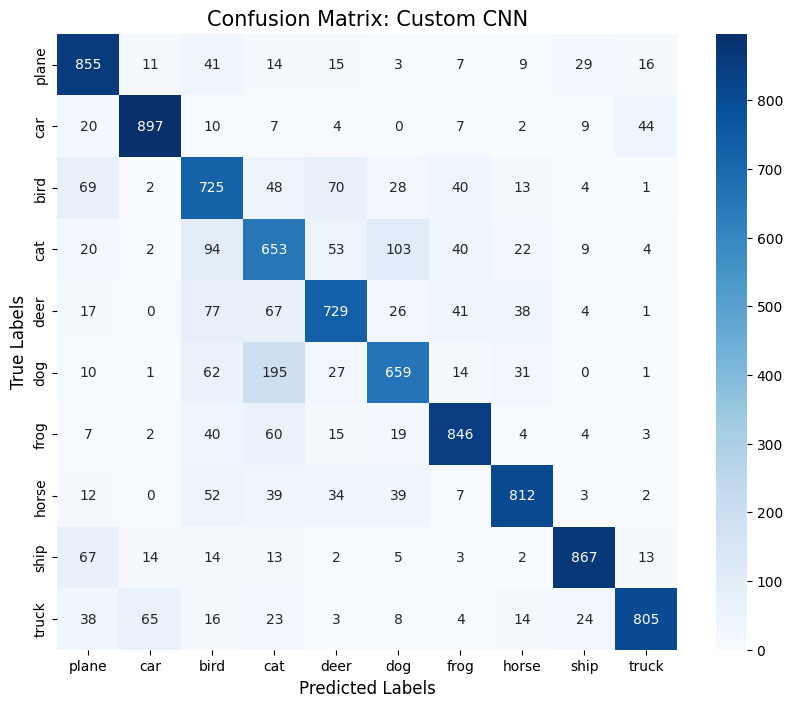

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataloader, model_name):
    print(f"Evaluating {model_name}...")
    model.eval() # Set model to evaluation mode

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1) # Get the index of the highest probability

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Print Classification Report (Accuracy, Precision, Recall, F1)
    print(f"\n--- Classification Report for {model_name} ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=15)
    plt.show()

# Run the evaluation on our Custom CNN using the test data
evaluate_model(custom_model, testloader, "Custom CNN")

Step 5: Transfer Learning with ResNet18

In [6]:
import torchvision.models as models

# 1. Load the pre-trained ResNet18 model
print("Loading pre-trained ResNet18...")
weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=weights)

# 2. Freeze all the core layers so we don't spend time training them
for param in resnet_model.parameters():
    param.requires_grad = False

# 3. Replace the final layer (the "head" of the model)
# ResNet18's final layer is called 'fc'. It normally outputs 1000 classes.
# We will replace it with a new layer that outputs our 10 CIFAR-10 classes.
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

# Move the model to the GPU
resnet_model = resnet_model.to(device)

# 4. Define a new optimizer
# Notice we are ONLY giving it the parameters of our new 'fc' layer to train!
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# 5. Train it! We get to reuse the exact same training loop from Step 3.
print("Starting training for Transfer Learning Model...")
# We can do fewer epochs here because it learns incredibly fast
resnet_train_losses, resnet_val_losses = train_model(resnet_model, optimizer_resnet, num_epochs=10, patience=3)

Loading pre-trained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]

Starting training for Transfer Learning Model...
Starting training for ResNet...


Epoch [1/10] | Train Loss: 1.7378 | Val Loss: 1.6321
Epoch [2/10] | Train Loss: 1.5994 | Val Loss: 1.6204
Epoch [3/10] | Train Loss: 1.5919 | Val Loss: 1.5933
Epoch [4/10] | Train Loss: 1.5804 | Val Loss: 1.5775
Epoch [5/10] | Train Loss: 1.5766 | Val Loss: 1.5717
Epoch [6/10] | Train Loss: 1.5698 | Val Loss: 1.5645
Epoch [7/10] | Train Loss: 1.5708 | Val Loss: 1.5671
Epoch [8/10] | Train Loss: 1.5646 | Val Loss: 1.5915
Epoch [9/10] | Train Loss: 1.5709 | Val Loss: 1.5612
Epoch [10/10] | Train Loss: 1.5619 | Val Loss: 1.5784
Training completed in 3.45 minutes.


ResNet18 was pre-trained on a dataset called ImageNet, which uses massive, high-resolution images (224x224 pixels). Our CIFAR-10 images are tiny (32x32 pixels). When you force a tiny 32x32 image through ResNet18, the network shrinks it down so fast that by the time it reaches the final layer, the image is practically gone. The "frozen brain" of ResNet is looking for big, clear features and gets confused by the tiny, pixelated CIFAR images. Also, ResNet expects a very specific color normalization that we didn't use.

The Fix
To make ResNet work its magic, we need to adapt our data to fit the model. We are going to resize our CIFAR-10 images to 224x224 and use the specific ImageNet color normalization.

In [7]:
# 1. Specific Transforms for ResNet (Resize and ImageNet Normalization)
transform_resnet_train = transforms.Compose([
    transforms.Resize(224), # Upscale the tiny images!
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_resnet_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Create New DataLoaders just for ResNet
print("Prepping resized data for ResNet...")
trainset_res = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_resnet_train)
trainloader_res = torch.utils.data.DataLoader(trainset_res, batch_size=64, shuffle=True, num_workers=2)

testset_res = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_resnet_test)
testloader_res = torch.utils.data.DataLoader(testset_res, batch_size=64, shuffle=False, num_workers=2)

# 3. Reload ResNet18 (to start fresh)
print("Reloading ResNet18...")
weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=weights)

# Freeze core layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace head
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# 4. Updated Training Function (accepts specific dataloaders)
def train_model_v2(model, optimizer, train_loader, test_loader, num_epochs=10, patience=3):
    print(f"Starting training for {model.__class__.__name__} with Resized Data...")
    start_time = time.time()
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_resnet.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"\nEarly stopping triggered!")
                break

    model.load_state_dict(torch.load('best_resnet.pth'))
    print(f"Training completed in {(time.time() - start_time)/60:.2f} minutes.")

# 5. RUN IT!
train_model_v2(resnet_model, optimizer_resnet, trainloader_res, testloader_res, num_epochs=10, patience=3)

Prepping resized data for ResNet...
Reloading ResNet18...
Starting training for ResNet with Resized Data...
Epoch [1/10] | Train Loss: 0.8177 | Val Loss: 0.6263
Epoch [2/10] | Train Loss: 0.6166 | Val Loss: 0.5870
Epoch [3/10] | Train Loss: 0.5939 | Val Loss: 0.5764
Epoch [4/10] | Train Loss: 0.5814 | Val Loss: 0.5925
Epoch [5/10] | Train Loss: 0.5721 | Val Loss: 0.5749
Epoch [6/10] | Train Loss: 0.5638 | Val Loss: 0.5612
Epoch [7/10] | Train Loss: 0.5605 | Val Loss: 0.5573
Epoch [8/10] | Train Loss: 0.5602 | Val Loss: 0.5563
Epoch [9/10] | Train Loss: 0.5565 | Val Loss: 0.5529
Epoch [10/10] | Train Loss: 0.5529 | Val Loss: 0.5711
Training completed in 18.72 minutes.


The Final Comparison

Evaluating ResNet18 (Transfer Learning)...

--- Classification Report for ResNet18 (Transfer Learning) ---
              precision    recall  f1-score   support

       plane       0.85      0.81      0.83      1000
         car       0.87      0.91      0.89      1000
        bird       0.78      0.75      0.76      1000
         cat       0.68      0.72      0.70      1000
        deer       0.75      0.78      0.77      1000
         dog       0.81      0.72      0.76      1000
        frog       0.82      0.87      0.84      1000
       horse       0.82      0.84      0.83      1000
        ship       0.86      0.88      0.87      1000
       truck       0.90      0.86      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



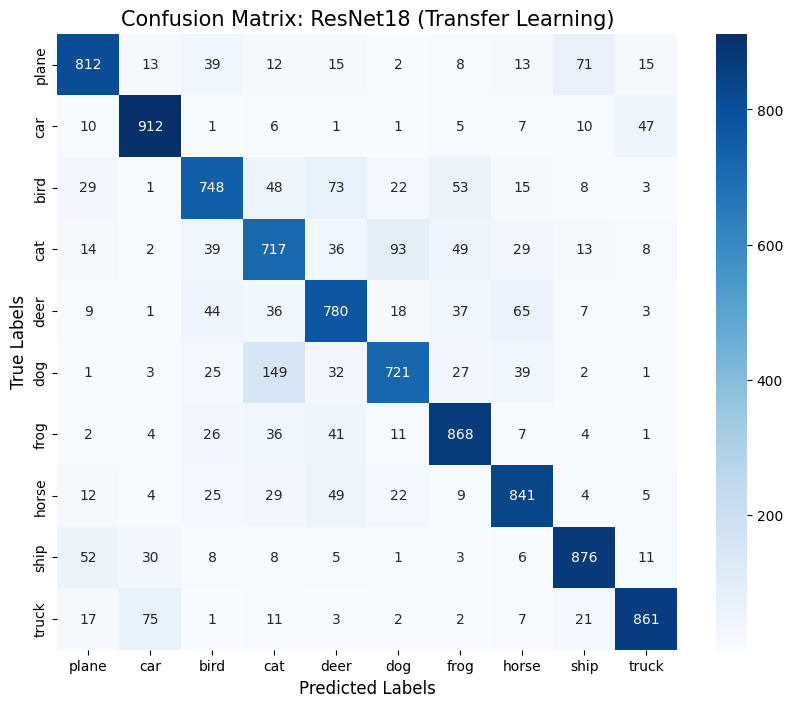

In [8]:
# Run the evaluation on our Transfer Learning model using the resized test data
evaluate_model(resnet_model, testloader_res, "ResNet18 (Transfer Learning)")

Step 5b: Fine-Tuning ResNet18 (Unfreezing Layers)

In [9]:
print("Reloading ResNet18 for Fine-Tuning...")
weights = models.ResNet18_Weights.DEFAULT
resnet_model_ft = models.resnet18(weights=weights)

# 1. Freeze EVERYTHING first
for param in resnet_model_ft.parameters():
    param.requires_grad = False

# 2. UNFREEZE the last convolutional block (layer4)
# This block contains a couple of layers, putting you right on par with your classmates!
print("Unfreezing 'layer4'...")
for param in resnet_model_ft.layer4.parameters():
    param.requires_grad = True

# 3. Replace the final decision layer (fc)
resnet_model_ft.fc = nn.Linear(resnet_model_ft.fc.in_features, 10)
resnet_model_ft = resnet_model_ft.to(device)

# 4. Collect only the unfrozen parameters for the optimizer
params_to_update = []
for param in resnet_model_ft.parameters():
    if param.requires_grad:
        params_to_update.append(param)

# We use a slightly lower learning rate to gently tweak the pre-trained weights
optimizer_ft = optim.Adam(params_to_update, lr=0.0005)

# 5. Train! (This might take a bit longer per epoch since it's doing more math)
train_model_v2(resnet_model_ft, optimizer_ft, trainloader_res, testloader_res, num_epochs=10, patience=3)

Reloading ResNet18 for Fine-Tuning...
Unfreezing 'layer4'...
Starting training for ResNet with Resized Data...
Epoch [1/10] | Train Loss: 0.4083 | Val Loss: 0.3232
Epoch [2/10] | Train Loss: 0.2239 | Val Loss: 0.3118
Epoch [3/10] | Train Loss: 0.1611 | Val Loss: 0.2761
Epoch [4/10] | Train Loss: 0.1128 | Val Loss: 0.2908
Epoch [5/10] | Train Loss: 0.0877 | Val Loss: 0.3085
Epoch [6/10] | Train Loss: 0.0697 | Val Loss: 0.3005

Early stopping triggered!
Training completed in 11.47 minutes.


Evaluating ResNet18 (Fine-Tuned)...

--- Classification Report for ResNet18 (Fine-Tuned) ---
              precision    recall  f1-score   support

       plane       0.90      0.94      0.92      1000
         car       0.98      0.91      0.94      1000
        bird       0.93      0.89      0.91      1000
         cat       0.81      0.82      0.82      1000
        deer       0.91      0.90      0.91      1000
         dog       0.86      0.84      0.85      1000
        frog       0.95      0.93      0.94      1000
       horse       0.90      0.95      0.92      1000
        ship       0.95      0.95      0.95      1000
       truck       0.93      0.96      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



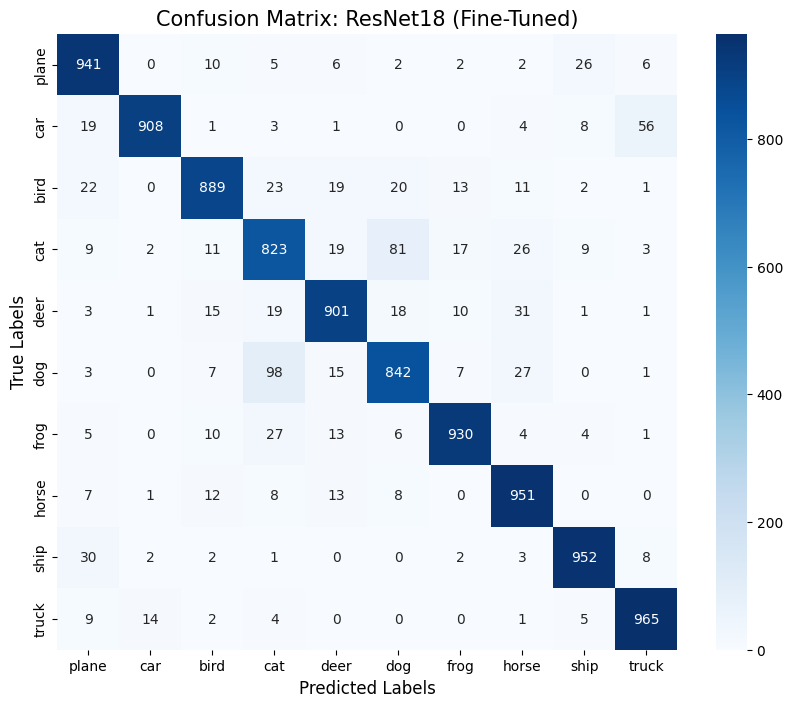

In [10]:
# In a new cell after it finishes training:
evaluate_model(resnet_model_ft, testloader_res, "ResNet18 (Fine-Tuned)")